Found 145 cases (2025-10-04 01 .. 2025-10-10 01)
Showing first 6 only (MAX_FRAMES)
[1/6] 2025-10-04 01:00


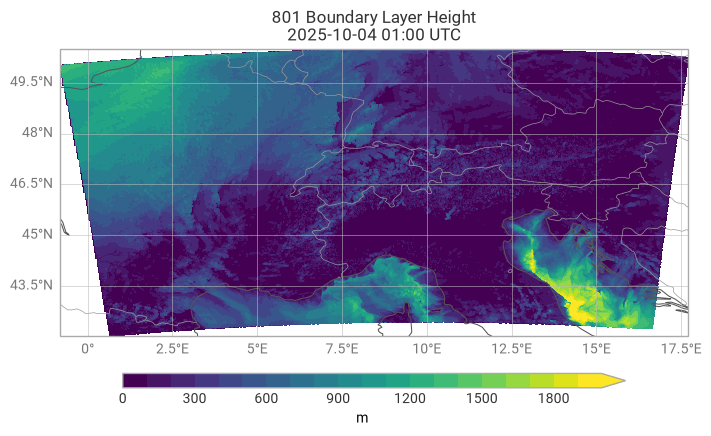

[2/6] 2025-10-04 02:00


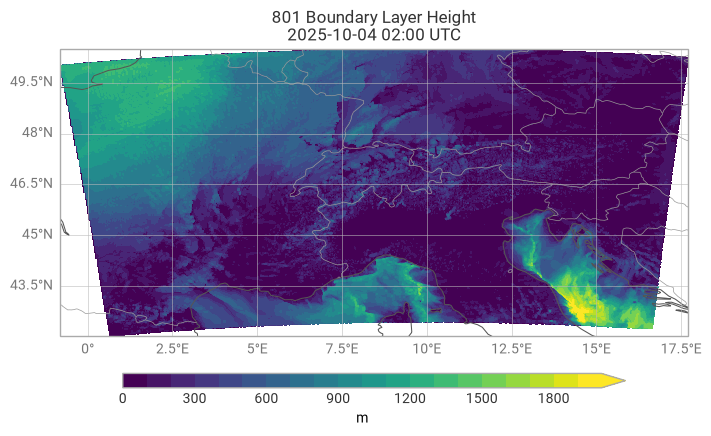

[3/6] 2025-10-04 03:00


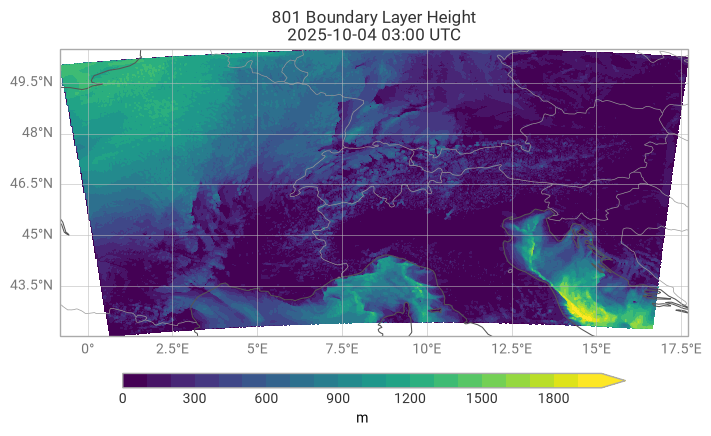

[4/6] 2025-10-04 04:00


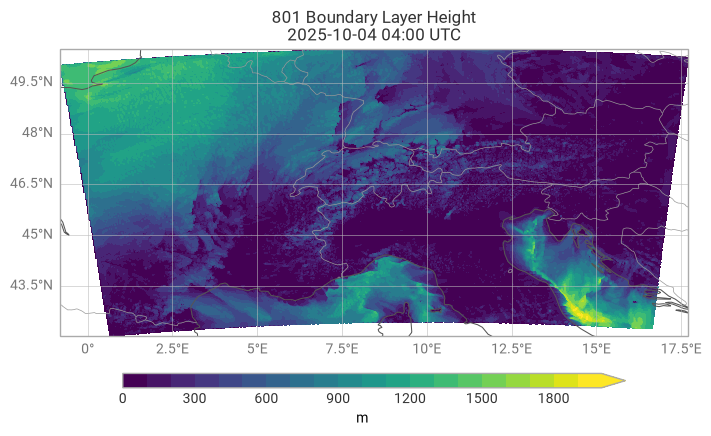

[5/6] 2025-10-04 05:00


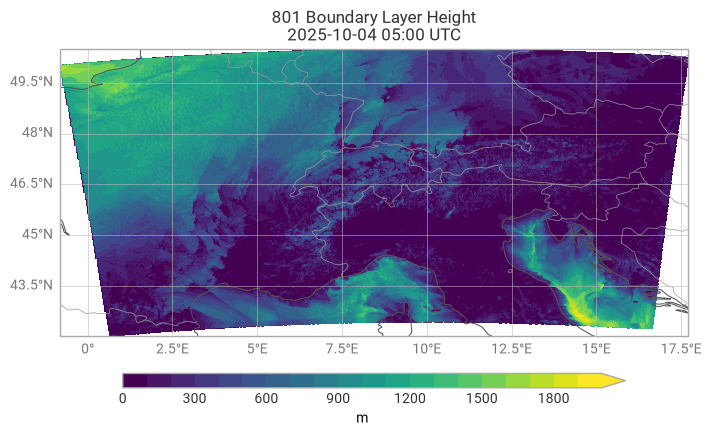

[6/6] 2025-10-04 06:00


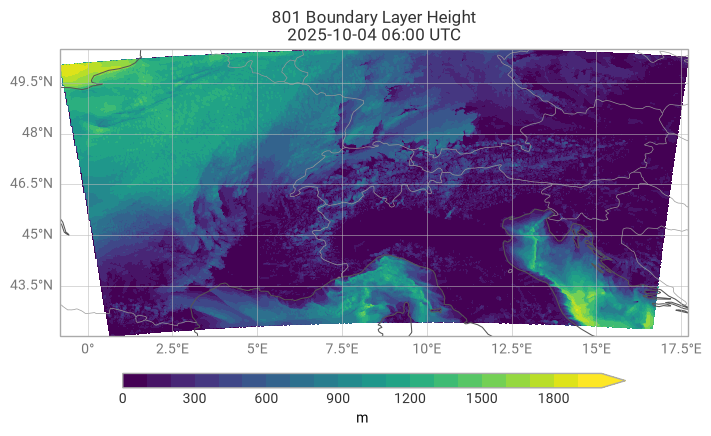


Done: 6 frame(s) plotted.


In [1]:
import os
os.environ["ECCODES_VERSION_CHECK_OFF"] = "1"

SAVE_FIGURES = False
SHOW_FIGURES = True
PARALLEL = True        # only takes effect when SAVE_FIGURES=True
MAX_WORKERS = 8
MAX_FRAMES = 6         # cap when SHOW_FIGURES=True; set None for no limit

import matplotlib
if SAVE_FIGURES:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
from datetime import datetime, timedelta

import earthkit.data as ekd
import earthkit.plots as ekp

# ==========================================================
# SETTINGS
# ==========================================================

SEARCH_START = datetime(2025, 10, 4, 0)
SEARCH_END = datetime(2025, 10, 10, 23)

EXP = "801"
HPBL_DIR = "/scratch/mch/jdelbeke/hpbl_test"
HPBL_NAME_FMT = "hpbl_" + EXP + "_{:%Y%m%d%H}.grb"

PARAM = "HPBL"
PARAM_LEVELS = list(range(0, 2100, 100))   # m
PARAM_CMAP = "viridis"

OUTPUT_DIR = os.path.expanduser(f"~/BLH_{EXP}")
if SAVE_FIGURES:
    os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==========================================================
# FILES
# ==========================================================

def find_hpbl(valid_time):
    path = os.path.join(HPBL_DIR, HPBL_NAME_FMT.format(valid_time))
    return path if os.path.exists(path) else None

def read_hpbl(grib_file):
    fields = ekd.from_source("file", grib_file).to_fieldlist()
    field = fields.sel({"parameter.variable": PARAM})
    if len(field) == 0:
        raise RuntimeError(f"{PARAM} not found in {grib_file}")
    return field

def collect_cases():
    cases = []
    t = SEARCH_START
    while t <= SEARCH_END:
        f = find_hpbl(t)
        if f:
            cases.append({"valid_time": t, "hpbl_file": f})
        t += timedelta(hours=1)
    return cases

# ==========================================================
# PROCESS ONE CASE
# ==========================================================

def process_case(case):
    valid_time = case["valid_time"]
    field = read_hpbl(case["hpbl_file"])

    chart = ekp.Map()
    chart.contourf(field, levels=PARAM_LEVELS, cmap=PARAM_CMAP, extend="max")
    chart.coastlines()
    chart.borders()
    chart.gridlines()
    chart.title(f"{EXP} Boundary Layer Height\n{valid_time:%Y-%m-%d %H:%M UTC}")
    chart.legend(label="m", shrink=0.8, pad=0.02)

    if SAVE_FIGURES:
        out_path = os.path.join(OUTPUT_DIR, f"BLH_{EXP}_{valid_time:%Y%m%d_%H%M}.png")
        chart.fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print("Saved:", out_path)

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(chart.fig)

# ==========================================================
# MAIN
# ==========================================================

if __name__ == "__main__":
    cases = collect_cases()
    if not cases:
        raise FileNotFoundError(f"No {PARAM} files found in {HPBL_DIR}")
    print(f"Found {len(cases)} cases "
          f"({cases[0]['valid_time']:%Y-%m-%d %H} .. {cases[-1]['valid_time']:%Y-%m-%d %H})")

    if SHOW_FIGURES and MAX_FRAMES:
        cases = cases[:MAX_FRAMES]
        print(f"Showing first {len(cases)} only (MAX_FRAMES)")

    if PARALLEL and SAVE_FIGURES:
        import concurrent.futures
        with concurrent.futures.ProcessPoolExecutor(max_workers=MAX_WORKERS) as pool:
            list(pool.map(process_case, cases))
        n_processed = len(cases)
    else:
        for n_processed, case in enumerate(cases, start=1):
            print(f"[{n_processed}/{len(cases)}] {case['valid_time']:%Y-%m-%d %H:%M}")
            process_case(case)

    print(f"\nDone: {n_processed} frame(s) plotted.")